# Peer Influence in Wave 2: Standardized Linear Regression

## Objective
To analyze how **Wave 2 Peer Depression** influences **Wave 2 Own Depression**.

## Methodology
1.  **Variables**:
    *   **Independent (X)**: Average Depression Score of Friends (in W2).
    *   **Dependent (Y)**: Student's Own Depression Score (in W2).
2.  **Preprocessing**:
    *   Calculate raw scores (Sum of v55 items).
    *   Compute peer averages based on the `Offline_Like` network.
    *   **Standardize** both X and Y (Z-Score) to make coefficients comparable.
3.  **Model**:
    *   Simple Linear Regression (OLS).
    *   Equation: $Z_{Self} = \beta \cdot Z_{Peer} + \epsilon$

## Interpretation
The Beta coefficient ($\beta$) represents the **Effect Size**: For every 1 standard deviation increase in peer depression, how many standard deviations does the student's own depression increase?
---

In [5]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
from scipy.stats import zscore
import matplotlib.pyplot as plt
import seaborn as sns
import os

# --- Paths ---
# Assuming we are in Code/EDA/mental_check/correlation_between_years_affected_by_peers
DATA_PATH = r"../../../../Data/2024data/TIGPS_W2_studentdata_ver5_cleaned_mental_common_only.csv"
RELATIONSHIP_PATH = r"../../relationship/Offline_Like.csv"

# Mental Health Columns (W2)
MH_COLS = [f"v55_{i}" for i in range(1, 15)]

In [6]:
def load_and_process():
    print("1. Loading W2 Data...")
    # Load Student Data
    df = pd.read_csv(DATA_PATH, on_bad_lines='skip', engine='python')
    
    # Calculate Own Score
    df['w2_own_score'] = df[MH_COLS].apply(pd.to_numeric, errors='coerce').sum(axis=1, min_count=1)
    
    # Filter valid students (must have score and ID)
    valid_students = df.dropna(subset=['w2_own_score', 'student_id']).copy()
    print(f"   Valid Students with Scores: {len(valid_students)}")
    
    # --- Build Peer Map ---
    print("2. Calculating Peer Scores...")
    # Create Lookup: (School, Class, Seat) -> (Student ID, Score)
    lookup = {}
    
    def clean_cls(v):
        return str(v).replace('.0', '').strip()
        
    for idx, row in valid_students.iterrows():
        try:
            sch = int(pd.to_numeric(row['school_id'], errors='coerce'))
            cls = clean_cls(row['class'])
            seat = int(pd.to_numeric(row['v13'], errors='coerce'))
            
            key = (sch, cls, seat)
            lookup[key] = (row['student_id'], row['w2_own_score'])
        except:
            continue
            
    # Parsing Edges
    edges = pd.read_csv(RELATIONSHIP_PATH)
    peer_data = {} # student_id -> list of friend scores
    
    for _, row in edges.iterrows():
        src_id = row['student_id']
        
        # Target Info
        try:
            ts = int(pd.to_numeric(row['school_id'], errors='coerce'))
            tc = clean_cls(row['class'])
            tn = int(pd.to_numeric(row['nominated_seat_no'], errors='coerce'))
            
            tgt_key = (ts, tc, tn)
            
            if tgt_key in lookup:
                tgt_id, tgt_score = lookup[tgt_key]
                
                if src_id not in peer_data:
                    peer_data[src_id] = []
                peer_data[src_id].append(tgt_score)
        except:
            continue
            
    # Calculate Averages
    peer_avg_list = []
    for sid, scores in peer_data.items():
        peer_avg_list.append({
            'student_id': sid,
            'w2_peer_avg': np.mean(scores),
            'friend_count': len(scores)
        })
    
    peer_df = pd.DataFrame(peer_avg_list)
    print(f"   Students with valid friends: {len(peer_df)}")
    
    # Merge Self + Peer
    final_df = pd.merge(valid_students[['student_id', 'w2_own_score']], peer_df, on='student_id', how='inner')
    print(f"   Final Analysis Sample: {len(final_df)}")
    
    return final_df

df = load_and_process()

1. Loading W2 Data...
   Valid Students with Scores: 7175
2. Calculating Peer Scores...
   Students with valid friends: 6593
   Final Analysis Sample: 6593


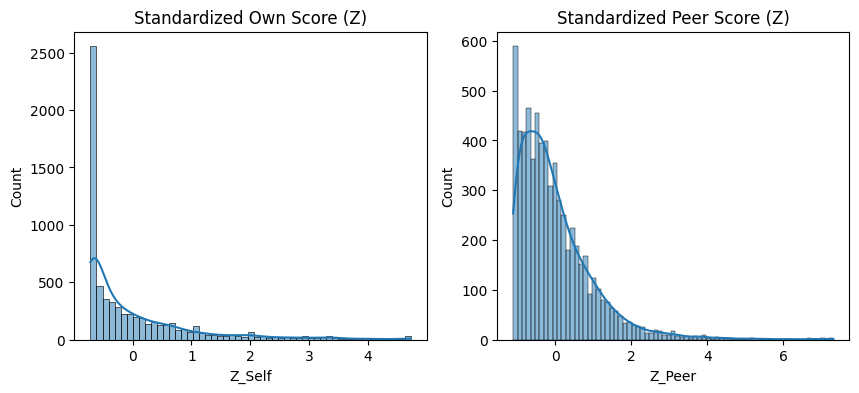

In [7]:
# --- 3. Standardization (Z-Score) ---
df['Z_Self'] = zscore(df['w2_own_score'])
df['Z_Peer'] = zscore(df['w2_peer_avg'])

# Check for normality (Optional visualization)
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
sns.histplot(df['Z_Self'], kde=True)
plt.title("Standardized Own Score (Z)")

plt.subplot(1, 2, 2)
sns.histplot(df['Z_Peer'], kde=True)
plt.title("Standardized Peer Score (Z)")
plt.show()

In [8]:
# --- 4. Linear Regression (OLS) ---
print("Running Standardized Linear Regression...")

# X = Peer (Independent)
X = df['Z_Peer']
X = sm.add_constant(X) # Add intercept

# Y = Self (Dependent)
y = df['Z_Self']

model = sm.OLS(y, X).fit()
print(model.summary())

Running Standardized Linear Regression...
                            OLS Regression Results                            
Dep. Variable:                 Z_Self   R-squared:                       0.036
Model:                            OLS   Adj. R-squared:                  0.036
Method:                 Least Squares   F-statistic:                     249.5
Date:                Tue, 13 Jan 2026   Prob (F-statistic):           3.47e-55
Time:                        17:16:48   Log-Likelihood:                -9232.6
No. Observations:                6593   AIC:                         1.847e+04
Df Residuals:                    6591   BIC:                         1.848e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const     

In [9]:
# --- 5. Key Results ---
beta = model.params['Z_Peer']
p_value = model.pvalues['Z_Peer']
r_squared = model.rsquared

print("\n--- Analysis Conclusion ---")
print(f"Beta (Standardized Coefficient): {beta:.4f}")
print(f"P-Value: {p_value:.4e}")
print(f"R-Squared: {r_squared:.4f}")

print("\nInterpretation:")
if p_value < 0.05:
    print(f"Result is Statistically Significant.")
    print(f"For every 1 Standard Deviation increase in Peer Depression, Own Depression increases by {beta:.4f} SDs.")
    print("This confirms 'Homophily' or 'Peer Effect' exists in Wave 2.")
else:
    print("Result is NOT Statistically Significant (p >= 0.05).")


--- Analysis Conclusion ---
Beta (Standardized Coefficient): 0.1910
P-Value: 3.4742e-55
R-Squared: 0.0365

Interpretation:
Result is Statistically Significant.
For every 1 Standard Deviation increase in Peer Depression, Own Depression increases by 0.1910 SDs.
This confirms 'Homophily' or 'Peer Effect' exists in Wave 2.
